In [1]:
from pathlib import Path
import sys

candidates = [Path.cwd(), Path.cwd().parent]
project_root = next(path for path in candidates if (path / "src" / "personal_finance_analyzer").exists())
sys.path.insert(0, str(project_root / "src"))



In [2]:
import pandas as pd
from IPython.display import Image, display
from personal_finance_analyzer import FinanceAnalyzer, FinanceVisualizer, load_transactions

## Load and validate the dataset

load_transactions reads the CSV file, converts the date and amount columns to appropriate data types, checks the required columns, and sorts all transactions by date.

In [4]:
data_path = project_root / "data" / "Personal_Finance_Dataset.csv"
transactions = load_transactions(data_path)
transactions.head(10)

,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense
5,2020-01-14,Benefit suggest page southern.,Shopping,448.68,Expense
6,2020-01-18,By two bad fall pick.,Food & Drink,1520.03,Expense
7,2020-01-19,Court attorney product significant world.,Other,3287.00,Income
8,2020-01-21,Herself law.,Entertainment,1914.85,Expense
9,2020-01-25,Have decide environment.,Rent,766.06,Expense


## dataset inspection




In [6]:
print(f"number of rows: {len(transactions)}")
print(f"number of columns: {len(transactions.columns)}")


number of rows: 1500
number of columns: 5


### No missing values in the dataset


In [8]:
print(transactions.isna().sum())


Date                       0
Transaction Description    0
Category                   0
Amount                     0
Type                       0
dtype: int64


# Transaction types


In [10]:
print(transactions["Type"].value_counts())


Type
Expense    1222
Income      278
Name: count, dtype: int64


In [11]:
print("categories")
print(set(transactions["Category"]))
print("number of categories")
print(len(set(transactions["Category"])))


categories
{'Shopping', 'Salary', 'Investment', 'Rent', 'Entertainment', 'Food & Drink', 'Health & Fitness', 'Utilities', 'Travel', 'Other'}
number of categories
10


## Analysis


`FinanceAnalyzer` stores a copy of the transaction DataFrame and provides  methods for each part of the analysis.

In [13]:
analyzer = FinanceAnalyzer(transactions)

## Overall Financial Summary

The summary calculates income and expenses, and net income.


In [15]:
summary = analyzer.summary()
print("number of transactions:", summary["transactions"])
print("total income: ",round(summary['total_income'],2))
print("Total expenses: ",round(summary["total_expenses"],2))
print("Net income", round(summary["net_income"],2))


number of transactions: 1500
total income:  734087.0
Total expenses:  1227194.37
Net income -493107.37


## Monthly Net

Transactions are grouped by month.

In [17]:
monthly = analyzer.monthly_summary()
monthly.head()

Type,Month,Income,Expense,Net
0,2020-01,5578.0,17138.25,-11560.25
1,2020-02,20070.0,17108.41,2961.59
2,2020-03,3465.0,13581.81,-10116.81
3,2020-04,7370.0,16233.05,-8863.05
4,2020-05,6008.0,16846.13,-10838.13


## Expense analysis by category

Expense transactions are grouped by category to calculate the number of transactions, total spending and average transaction amount, where travel has the highest total expense . On the other hand, Food and drink has the highest mean across months

### Data observation
In this dataset, the income transaction belong to "Investment" and "Other", while salary is labeled as expeneses.

In [20]:
expense_categories = analyzer.expense_by_category()
expense_categories

,Category,count,sum,mean
0,Entertainment,143,148165.47,1036.122168
1,Food & Drink,149,159493.39,1070.425436
2,Health & Fitness,152,145194.06,955.224079
3,Rent,165,162075.39,982.275091
4,Salary,146,149053.55,1020.914726
5,Shopping,150,146880.75,979.205000
6,Travel,160,169497.79,1059.361188
7,Utilities,157,146833.97,935.248217


## Income analysis by category


In [22]:
income_categories = analyzer.income_by_category()
income_categories

,Category,Transactions,Total,Average
0,Other,136,370835.0,2726.727941
1,Investment,142,363252.0,2558.112676


## Large expenses
Detecting possible positive expenses outliers using rule q3 + 1,5 *IQR

In [24]:
large_expenses = analyzer.large_expenses()
print(f"Detected large expenses: {len(large_expenses)}")
large_expenses.head()

Detected large expenses: 0


,Date,Transaction Description,Category,Amount,Type


## Large Income
Detecting possible positive Income outliers using rule q3 + 1,5 *IQR

In [26]:
large_incomes = analyzer.large_incomes()
print(f"Detected large income: {len(large_incomes)}")
large_incomes.head()

Detected large income: 0


,Date,Transaction Description,Category,Amount,Type


## train and test
to evaluate the forecasting performance of the arima models we will divide data into train and test sets. Since this is time series data the observations will not be shuffled

In [28]:
train, test = analyzer.split_train_test(test_size=6)

print("Training:", len(train))
print("Test:", len(test))

Training: 54
Test: 6


## Forecast of the net income

Instead of predicting income and expenses individually we will predict the net income.
Auto Arima chooses the best Arima model with approperiate order of Auto regression , number of differences and the moving averages. The criteria of choosing the best model is based on AIC which represent loss of information across each model.
Another trial was done using BIC 


### Forecast evaluation metrics
- **MAE**: Measures absolute difference between predicted and the actual
- **RMSE**: Measure error in forecast with larger weight on bigger errors
- **MDA**: Measure the percentage of months in which model correctly predicts net will increase or decrease

### AIC
the selected model according to the AIC AR of order 2 and MA of order 0 and number of differences =0

In [32]:
auto_aic = analyzer.evaluate_auto_arima(
    information_criterion="aic",
    test_size=6
)

auto_aic_table = pd.DataFrame({
    "Metric": [
        "ARIMA Order",
        "AIC",
        "BIC",
        "MAE",
        "RMSE",
        "mda"
    ],
    "Value": [
        str(auto_aic["order"]),
        round(auto_aic["aic"], 2),
        round(auto_aic["bic"], 2),
        round(auto_aic["mae"], 2),
        round(auto_aic["rmse"], 2),
        round(auto_aic["mda"], 2)
    ]
})

auto_aic_table

,Metric,Value
0,ARIMA Order,"(2, 0, 0)"
1,AIC,1135.71
2,BIC,1143.67
3,MAE,5441.69
4,RMSE,6431.87
5,mda,0.0


### BIC
When we chose BIC we can see the auto arima chose same model. Selected model according to the BIC criterion is AR of order 2 and number of differences =0 and order of MA is 0.

We can clearly see that both models have mean direction accuracy of zero which mean that they never predict the direction correctly

In [34]:
auto_bic = analyzer.evaluate_auto_arima(
    information_criterion="bic",
    test_size=6
)

auto_bic_table = pd.DataFrame({
    "Metric": [
        "ARIMA Order",
        "AIC",
        "BIC",
        "MAE",
        "RMSE",
        "MDA (%)"
    ],
    "Value": [
        str(auto_bic["order"]),
        round(auto_bic["aic"], 2),
        round(auto_bic["bic"], 2),
        round(auto_bic["mae"], 2),
        round(auto_bic["rmse"], 2),
        round(auto_bic["mda"], 2)
    ]
})

auto_bic_table

,Metric,Value
0,ARIMA Order,"(2, 0, 0)"
1,AIC,1135.71
2,BIC,1143.67
3,MAE,5441.69
4,RMSE,6431.87
5,MDA (%),0.0


### Tests after plotting ACF and PACF  

In [36]:
ar3 = analyzer.evaluate_arima(
    p=3,
    d=0,
    q=0,
    test_size=6
)

print("Model:", ar3["order"])
print("AIC:", round(ar3["aic"], 2))
print("BIC:", round(ar3["bic"], 2))
print("MAE:", round(ar3["mae"], 2))
print("RMSE:", round(ar3["rmse"], 2))
print("mda:", round(ar3["mda"], 2))


Model: (3, 0, 0)
AIC: 1137.69
BIC: 1147.63
MAE: 5336.95
RMSE: 6375.41
mda: 20.0


In [37]:
ar4 = analyzer.evaluate_arima(
    p=4,
    d=0,
    q=0,
    test_size=6
)

print("Model:", ar4["order"])
print("AIC:", round(ar4["aic"], 2))
print("BIC:", round(ar4["bic"], 2))
print("MAE:", round(ar4["mae"], 2))
print("RMSE:", round(ar4["rmse"], 2))
print("mda:", round(ar4["mda"], 2))


Model: (4, 0, 0)
AIC: 1137.09
BIC: 1149.02
MAE: 4323.87
RMSE: 5559.4
mda: 80.0


In [38]:
ma2 = analyzer.evaluate_arima(
    p=0,
    d=0,
    q=2,
    test_size=6
)
print("Model:", ma2["order"])
print("AIC:", round(ma2["aic"], 2))
print("BIC:", round(ma2["bic"], 2))
print("MAE:", round(ma2["mae"], 2))
print("RMSE:", round(ma2["rmse"], 2))
print("mda:", round(ma2["mda"], 2))


Model: (0, 0, 2)
AIC: 1133.93
BIC: 1141.88
MAE: 5131.67
RMSE: 5955.58
mda: 40.0


### Summary of all models 
Lower AIC, BIC, MAE and RMSE is preferred, while higher MDA is better. Thus, the best model according to the metrics on test set is AR of order 4. Although the Moving average of order 2 has the best AIC and BIC but it has higher MAE, RMSE and lower MDA



In [40]:
model_comparison = pd.DataFrame({
    "Model": [
        "Auto-ARIMA",
        "AR(3)",
        "AR(4)",
        "MA(2)"
    ],
    "Order": [
        str(auto_aic["order"]),
        str(ar3["order"]),
        str(ar4["order"]),
        str(ma2["order"])
    ],
    "AIC": [
        auto_aic["aic"],
        ar3["aic"],
        ar4["aic"],
        ma2["aic"]
    ],
    "BIC": [
        auto_aic["bic"],
        ar3["bic"],
        ar4["bic"],
        ma2["bic"]
    ],
    "MAE": [
        auto_aic["mae"],
        ar3["mae"],
        ar4["mae"],
        ma2["mae"]
    ],
    "rmse": [
        auto_aic["rmse"],
        ar3["rmse"],
        ar4["rmse"],
        ma2["rmse"]
    ],
    "mda": [
        auto_aic["mda"],
        ar3["mda"],
        ar4["mda"],
        ma2["mda"]
    ]
})

model_comparison.round(2)

,Model,Order,AIC,BIC,MAE,rmse,mda
0,Auto-ARIMA,"(2, 0, 0)",1135.71,1143.67,5441.69,6431.87,0.0
1,AR(3),"(3, 0, 0)",1137.69,1147.63,5336.95,6375.41,20.0
2,AR(4),"(4, 0, 0)",1137.09,1149.02,4323.87,5559.40,80.0
3,MA(2),"(0, 0, 2)",1133.93,1141.88,5131.67,5955.58,40.0


## Residual diagnstic tests
After selecting the AR(4) model, residual tests are done to check if the residuals satisfy the assumptions

### Ljung box test
The ljung box test checks if AR(4) residuals containing remaining auto correlation
- H0: the residuals show no significant autocorrelation
- H1: the residuals show significant autocorrelation

Here the p-value is 0.45 so we fail to reject the null hypothesis that say that the residual has no significant auto correlation. This sugggests that AR(4) captures the main auto correlation structure in the data.

In [44]:
ljung_box = analyzer.ljung_box_test(p=4,d=0,q=0,test_size=6,lag=10)

ljung_box

{'lag': 10, 'statistic': 5.75103834397288, 'p_value': 0.4516488279319173}

### Shapiro Wilk statistic

The shapiro wilk statistic examines whether the AR(4) residuals are consistent with a normal distribution:
- **H0**: The residuals are normally distributed.
- **H1**: The residuals are not normally distributed.

We fail to reject h0, so no enough evidence to conclude that the residuals are not normally distributed

In [48]:
shapiro_result = analyzer.shapiro_wilk_test( p=4,d=0, q=0,test_size=6)

shapiro_result

{'statistic': 0.9836434902883455, 'p_value': 0.6670349179157584}

In [49]:
output_dir = project_root / "output"
output_dir.mkdir(exist_ok=True)
analyzer.monthly_summary().to_csv(output_dir / "monthly summary.csv",index=False)
analyzer.expense_by_category().to_csv(output_dir / "expense by category.csv",index=False)
analyzer.income_by_category().to_csv(output_dir / "income by category.csv",index=False)

## Visualizations

In [51]:
visualizer = FinanceVisualizer(analyzer)
figure_paths = visualizer.save_all(output_dir)
figure_paths

[WindowsPath('C:/Users/Lenovo/Downloads/personal_finance_analyzer_project/personal_finance_analyzer_project/output/category expenses.png'),
 WindowsPath('C:/Users/Lenovo/Downloads/personal_finance_analyzer_project/personal_finance_analyzer_project/output/monthly summary.png'),
 WindowsPath('C:/Users/Lenovo/Downloads/personal_finance_analyzer_project/personal_finance_analyzer_project/output/acf.png'),
 WindowsPath('C:/Users/Lenovo/Downloads/personal_finance_analyzer_project/personal_finance_analyzer_project/output/pacf.png'),
 WindowsPath('C:/Users/Lenovo/Downloads/personal_finance_analyzer_project/personal_finance_analyzer_project/output/ar4 predictions.png'),
 WindowsPath('C:/Users/Lenovo/Downloads/personal_finance_analyzer_project/personal_finance_analyzer_project/output/ar4 residual histogram.png'),
 WindowsPath('C:/Users/Lenovo/Downloads/personal_finance_analyzer_project/personal_finance_analyzer_project/output/ar4 QQ-plot.png')]

### Expenses
As illustrated in the graph, we can see that the differences between expenses are not big.

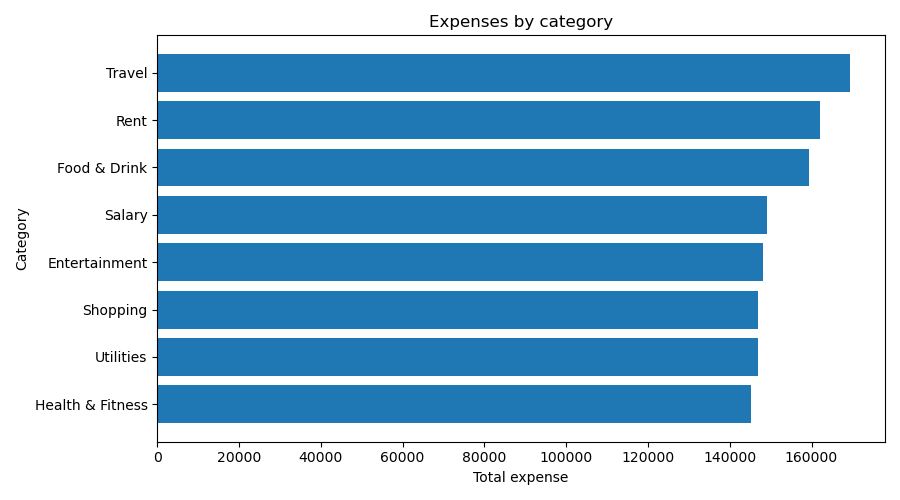

In [53]:
display(Image(filename=str(figure_paths[0])))

### Monthly income, Expense and net
Across most months, expenses are higher than income.
Since data is monthly, we can look for annual or semi annual seasonality. However as we can see from the data, no clear seasnality is observed.
There are clear major spikes in income in March 2021 and Dec 2021. 

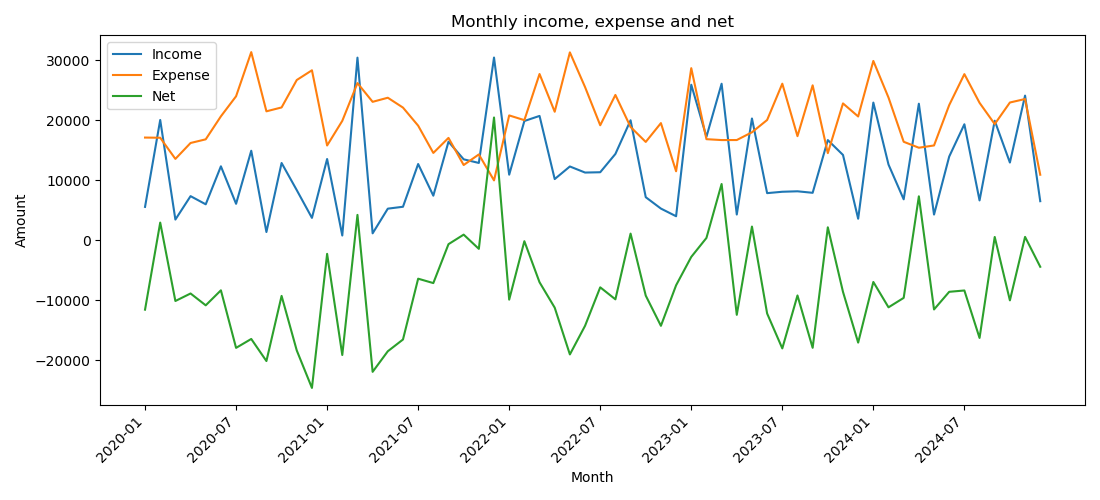

In [55]:
display(Image(filename=str(figure_paths[1])))

## ACF
Most auto correlation lies within confidence interval. One significant spike at lag 2 suggesting MA of order 2.  There is no significant spikes at annual or bi-annual lags so no clear evidence of seasonality

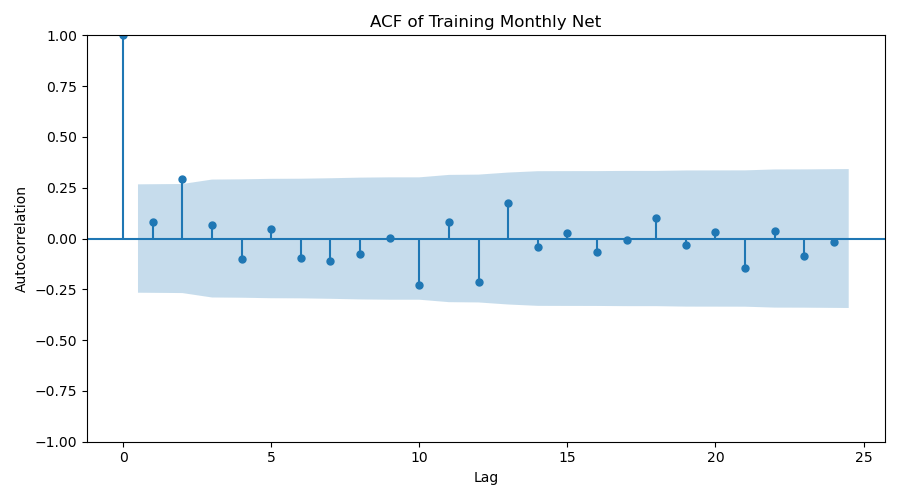

In [57]:
display(Image(filename=str(figure_paths[2])))

## PACF 
Most auto correlation lies within confidence interval. One significant spike at lag 2 suggesting AR of order 2.  There is no significant spikes at 12 or 24 so no clear annual seasonality

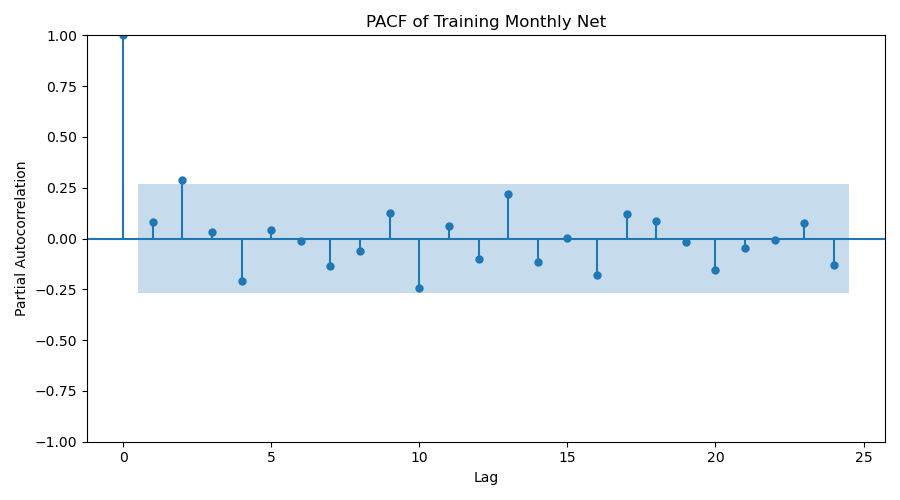

In [59]:
display(Image(filename=str(figure_paths[3])))

## Forecast AR(4) evaluation
we can see that the model was able to predict the direction accuratly in most cases but there is major problem of the model underestimating the magnitude of the fluctuations. All observed Net values are within the 95% confidence intervals. The intervals are very wide which indicate large uncertanity in the forecasts.


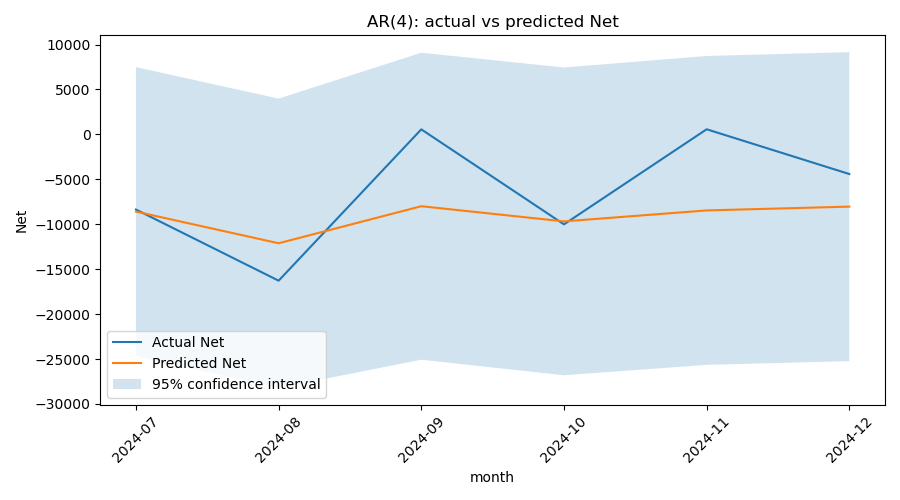

In [61]:
display(Image(filename=str(figure_paths[4])))

### Residual distribution
The AR(4) residuals are centered around the zero, which indicates that there is no under or over estimation.
The curve is almost bell shaped, so they follow approximately normal distribution

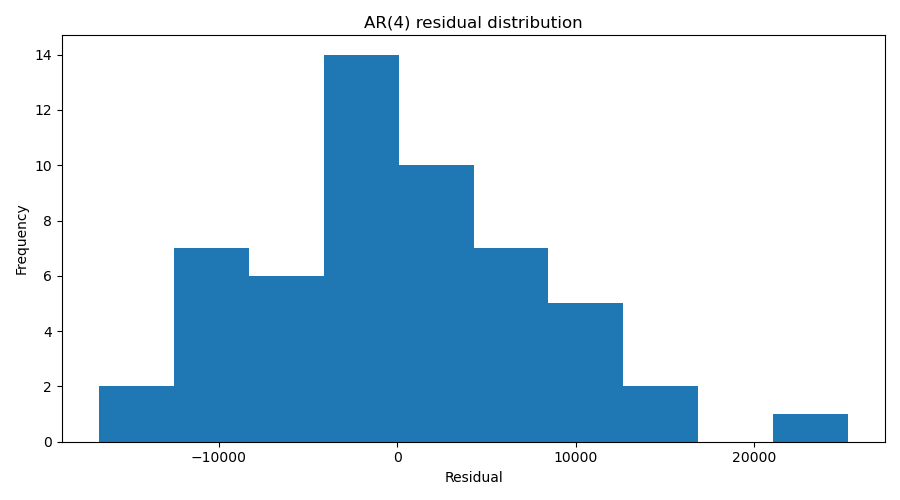

In [63]:
display(Image(filename=str(figure_paths[5])))

### Residual QQ-plot
Most of the points lie on the line , which indicates that the residuals are consistent with the normality assumption

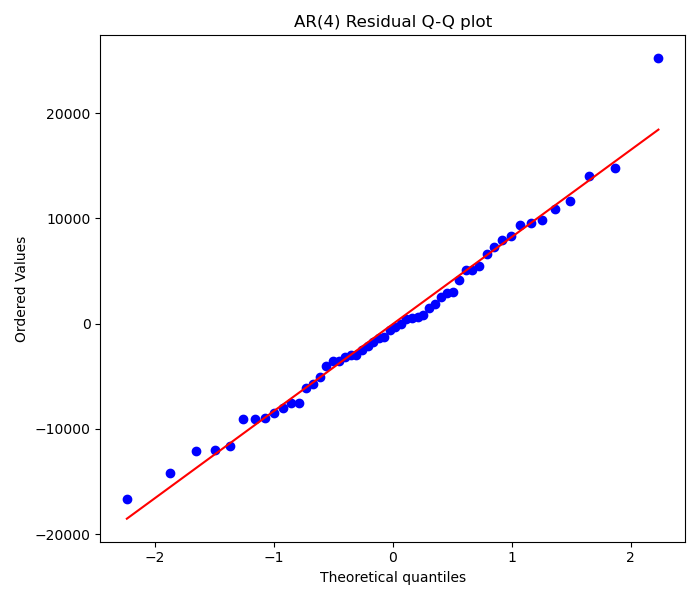

In [65]:
display(Image(filename=str(figure_paths[6])))